In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from dotenv import load_dotenv
load_dotenv()

DATA_LOC = os.getenv("DATA_LOC")
print(DATA_LOC)



~/Data/DCIA_DATA/Data/GENERAL SOURCES


### GPKG file

In [3]:
gdf_loc = os.path.join(DATA_LOC, "2025-cbs_pc4_2024_v1/cbs_pc4_2024_v1.gpkg")
gdf = gpd.read_file(gdf_loc)
gdf.head()

,postcode,aantal_inwoners,aantal_mannen,aantal_vrouwen,aantal_inwoners_0_tot_15_jaar,aantal_inwoners_15_tot_25_jaar,aantal_inwoners_25_tot_45_jaar,aantal_inwoners_45_tot_65_jaar,aantal_inwoners_65_jaar_en_ouder,aantal_geboorten,...,ziekenhuis_excl_buitenpoli_aantal_binnen_20_km,dichtstbijzijnde_ziekenh_incl_buitenpoli_afst_in_km,ziekenhuis_incl_buitenpoli_aantal_binnen_5_km,ziekenhuis_incl_buitenpoli_aantal_binnen_10_km,ziekenhuis_incl_buitenpoli_aantal_binnen_20_km,dichtstbijzijnde_apotheek_afstand_in_km,dichtstbijzijnde_huisartsenpost_afstand_in_km,omgevingsadressendichtheid,stedelijkheid,geometry
0,1184,625,325,300,90,105,95,220,110,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,587,4,"MULTIPOLYGON (((121294.898 478995.348, 121150...."
1,1405,2845,1360,1485,595,345,470,890,545,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,2302,2,"MULTIPOLYGON (((139183.019 477105.269, 139183...."
2,1411,10495,5065,5430,1820,1115,2070,3080,2405,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,964,4,"MULTIPOLYGON (((138164.963 479489.548, 138179...."
3,1695,5420,2630,2790,930,550,1210,1175,1555,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,1727,2,"MULTIPOLYGON (((136303.479 518824.318, 136388...."
4,1861,6455,3020,3435,700,580,760,1930,2485,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,1122,3,"MULTIPOLYGON (((107950.64 519128.923, 107950.6..."


<Axes: >

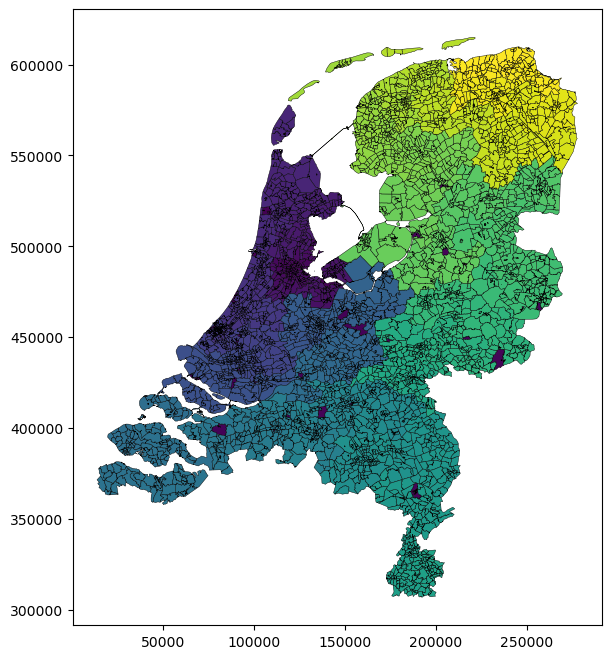

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
) #Look at that its NL


In [74]:
print(gdf.shape)

(4071, 137)


Indicators:
- 137 indicators. Find their list and translations in cbs_pc4_column_translations.txt
- Indicators contain the number of people per age group, gender, number of households, number of dwelllings, average income etc. (These are the same as in the excel)
- It also includes the number of different facilities within some distance. Both cultural facilities such as  cafés, supermarkets, stores, doctors offices, hotels, restaurants, schools, etc.
- We can use these data to identify need for facilities, by looking at what they do not have nearby. Both cultural, social as well as health


### XLSX file

Resident, household, and housing data for the numeric part of the postal code (that is 4 letters), reference date January 1, 2024

In [8]:
df_loc = os.path.join(DATA_LOC, "2025-cbs_pc4_2024_v1", "pc4_2024_v1.xlsx")
df = pd.read_excel(df_loc, skiprows=5, header=[0, 1, 2, 3])
#column names are split across 3 rows, combining them


#Remove the top 2 unnamed levels for postcode-4
cols = list(df.columns)
cols[0] = ('Postcode-4', '', '', '')
df.columns = pd.MultiIndex.from_tuples(cols)

print(df.shape)
df.head()

(4072, 37)


Postcode-4 Inwoners                                                 \
               Totaal Geslacht        Leeftijdklassen                  
               Totaal      Man  Vrouw     tot 15 jaar 15 tot 25 jaar   
                   x1       x1     x1              x1             x1   
0       1011    10010     5160   4850             680           1330   
1       1012     9120     4905   4215             335           1770   
2       1013    23020    11675  11345            2210           2800   
3       1014     4950     2480   2475             835            590   
4       1015    14965     7465   7495            1055           1855   

                                                  \
                                                   
  25 tot 45 jaar 45 tot 65 jaar 65 jaar en ouder   
              x1             x1               x1   
0           3475           2495             2025   
1           4490           1695              825   
2           8515           5875             3625   
3           2290            910              325   
4           5370           4060             2620   

                                                     ...        Woning  \
                                           Herkomst  ...   Bouwperiode   
  Geboren in Nederland met een Nederlandse herkomst  ... 2005 tot 2015   
                                                  %  ...            x1   
0                                                50  ...           395   
1                                                40  ...           110   
2                                                40  ...          1285   
3                                                50  ...        -99997   
4                                                50  ...            85   

                                                                             \
                      Type              Eigendom                 In gebruik   
  2015 en later Meergezins Koopwoning Huurwoning Huurcoporatie Niet bewoond   
             x1         x1          %          %            x1           x1   
0           140       6145         30         70          2470          625   
1            50       5770         20         80           715          985   
2           675      12600         30         70          6435          750   
3          2035       2200         40         60           330          195   
4            15       9500         30         70          3480         1035   

                                                   Sociale Zekerheid  \
                                                  Totaal uitkeringen   
  Personen met WW, Bijstand en/of AO uitkering\nBeneden AOW-leeftijd   
                                                                  x1   
0                                                590                   
1                                                385                   
2                                               2090                   
3                                                180                   
4                                               1110                   

                   Dichtheid                      
  Omgevingsadressendichtheid       Stedelijkheid  
         Unnamed: 35_level_2 Unnamed: 36_level_2  
                adressen/km2           categorie  
0                       7176                   1  
1                       8654                   1  
2                       6691                   1  
3                       3606                   1  
4                      11169                   1  

[5 rows x 37 columns]

In [67]:
print(df.columns)

MultiIndex([(       'Postcode-4',                           '', ...),
            (         'Inwoners',                     'Totaal', ...),
            (         'Inwoners',                   'Geslacht', ...),
            (         'Inwoners',                   'Geslacht', ...),
            (         'Inwoners',            'Leeftijdklassen', ...),
            (         'Inwoners',            'Leeftijdklassen', ...),
            (         'Inwoners',            'Leeftijdklassen', ...),
            (         'Inwoners',            'Leeftijdklassen', ...),
            (         'Inwoners',            'Leeftijdklassen', ...),
            (         'Inwoners',                   'Herkomst', ...),
            (         'Inwoners',                   'Herkomst', ...),
            (         'Inwoners',                   'Herkomst', ...),
            (         'Inwoners',                   'Herkomst', ...),
            (         'Inwoners',                   'Herkomst', ...),
            (       

We have 36 indicators for 4073 4 letter postcode regions. Be careful when using these as the column headers have 4 levels

Indicators:
- Postcode-4: postcode_4

- Inwoners: residents
- Totaal: total
- Geslacht: gender
- Leeftijdklassen: age_classes
- Herkomst: origin

- Huishouden: household
- Samenstelling: composition
- Grootte: size

- Woning: dwelling
- Bouwperiode: construction_period
- Type: type
- Eigendom: ownership
- In gebruik: in_use

- Sociale Zekerheid: social_security
- Totaal uitkeringen: total_benefits

- Dichtheid: density
- Omgevingsadressendichtheid: address_density
- Stedelijkheid: urbanization

### Summary: the excel is 4 post code level and contains information on the type of apartments, the number, number of people by gender and age. It also contains information on how urbanized and dense the region is, and on social security and benefits